# Wedding Organizer CBIR (Content-Based Image Retrieval) Playground
Notebook ini untuk **Eksplorasi Data**, **Ekstraksi Fitur**, **Pencarian Gambar Serupa**, dan **Evaluasi** sistem CBIR Wedding Organizer.

## Fitur Utama
1. **CombinedExtractor (default)**: ResNet50 (2048)x70% + HSV ColorHist (512)x20% + LBP (256)x10% = **2816-dim**
2. **UltraCombinedExtractor**: 11 fitur (ResNet50, EfficientNet, VGG16, HOG, ColorHist, RGB, Gabor, LBP, SIFT, AKAZE, DominantColor) = **~11.364-dim**
3. **Individual**: Deep (ResNet50/EfficientNet/VGG16), Color (HSV/RGB/Dominant), Texture (LBP/Gabor), Shape (HOG), Keypoint (SIFT/AKAZE/ORB)
4. **Similarity Metrics**: Euclidean (default), Cosine, Manhattan
5. **Evaluasi**: MAP, MRR, First Rank Accuracy, Query Time Benchmark

In [2]:
import os, sys, json, time, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

BASE_DIR = os.getcwd()
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

from src.addons.extraction.extractor import get_extractor, extractors
from src.addons.finder import get_finder
from src.addons.data import load_feature_database, load_dataset_csv, resolve_portable_path
from src.addons.metrics import evaluation_report, benchmark_query_time

print("Library berhasil di-import!")

Library berhasil di-import!


---
## 1. Eksplorasi Data (dataset.csv)
Memuat data dari Laravel (products + packages wedding).

In [3]:
csv_path = os.path.join("data", "dataset.csv")
df = pd.read_csv(csv_path)

print(f"Total data: {len(df)} baris, {len(df.columns)} kolom")
print(f"Kolom: {list(df.columns)}")
display(df[['ID','Type','Name','Category','Price','Discount_Price']].head(20))

Total data: 20 baris, 24 kolom
Kolom: ['ID', 'Type', 'Name', 'Category', 'Price', 'Discount_Price', 'Organizer', 'Image_Path', 'Description', 'features', 'features_combined', 'features_deep', 'features_resnet50', 'features_efficientnet', 'features_vgg16', 'features_color', 'features_color_hist', 'features_rgb', 'features_dominant', 'features_lbp', 'features_gabor', 'features_hog', 'features_sift', 'features_akaze']


,ID,Type,Name,Category,Price,Discount_Price
0,1,product,Gebyok Ukir Jati Premium,Traditional,15000000.0,NaN
1,2,product,Chandelier Kristal Modern,Modern,20000000.0,18000000.0
2,3,product,Arch Kayu Rustic Natural,Rustic,8500000.0,NaN
3,4,product,Flower Wall Blush Rose,Minimalist,6500000.0,5800000.0
4,5,product,Pergola Taman Inggris,Garden,12000000.0,NaN
5,6,product,Pelaminan Emas Royal,Royal,35000000.0,32000000.0
6,7,product,Macrame Bohemian Backdrop,Rustic,4500000.0,NaN
7,8,product,Neon Sign Custom Wedding,Modern,3500000.0,3000000.0
8,9,product,Candelabra Set Mewah,Royal,9000000.0,NaN
9,10,product,Greenery Wall Skandinavia,Minimalist,5500000.0,5000000.0


In [4]:
# Statistik
print(f"Products: {len(df[df['Type']=='product'])} | Packages: {len(df[df['Type']=='package'])}")
print(f"Kategori: {df['Category'].value_counts().to_dict()}")
print(f"Harga: min=Rp {df['Price'].min():,.0f}  max=Rp {df['Price'].max():,.0f}  mean=Rp {df['Price'].mean():,.0f}")
print(f"Ada diskon: {(~df['Discount_Price'].isna()).sum()} item")

Products: 10 | Packages: 10
Kategori: {'Modern': 4, 'Rustic': 4, 'Royal': 4, 'Traditional': 3, 'Minimalist': 3, 'Garden': 2}
Harga: min=Rp 3,500,000  max=Rp 50,000,000  mean=Rp 18,950,000
Ada diskon: 11 item


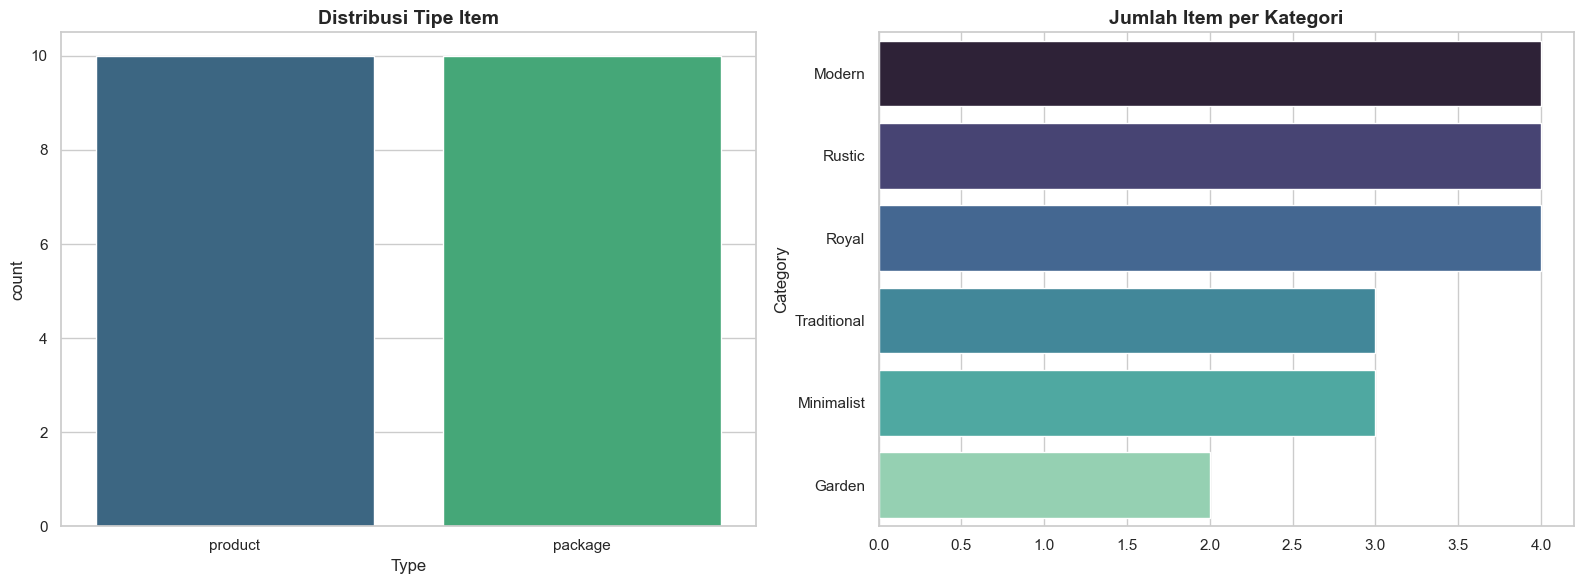

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='Type', hue='Type', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Tipe Item', fontsize=14, fontweight='bold')

cat_counts = df['Category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette='mako', ax=axes[1])
axes[1].set_title('Jumlah Item per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

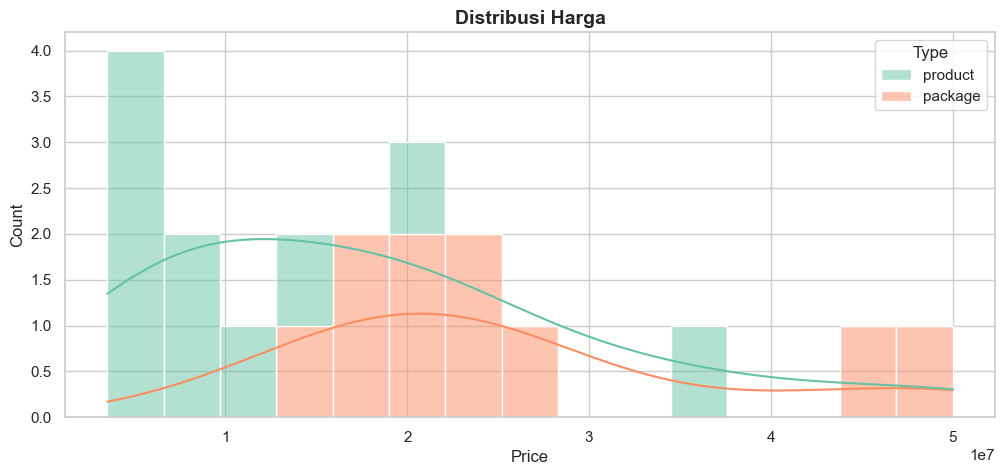

In [6]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Price', hue='Type', kde=True, bins=15, palette='Set2', multiple='stack')
plt.title('Distribusi Harga', fontsize=14, fontweight='bold'); plt.show()

### 1a. Validasi Path Gambar
Cek apakah semua file gambar benar-benar ada di disk.

In [7]:
rows = load_dataset_csv(csv_path)
print(f"{'ID':>3} {'Type':>8} {'Exists':>6}  Name")
print('-'*60)
found_total = 0
for r in rows:
    raw_path = r.get('Image_Path','').strip()
    resolved = resolve_portable_path(raw_path)
    exists = os.path.exists(resolved)
    if exists: found_total += 1
    print(f"{int(r['ID']):3d} {r['Type']:>8} {str(exists):>6}  {r['Name'][:40]}")
print(f"\nFound on disk: {found_total}/{len(rows)}")

 ID     Type Exists  Name
------------------------------------------------------------
  1  product   True  Gebyok Ukir Jati Premium
  2  product   True  Chandelier Kristal Modern
  3  product   True  Arch Kayu Rustic Natural
  4  product   True  Flower Wall Blush Rose
  5  product   True  Pergola Taman Inggris
  6  product   True  Pelaminan Emas Royal
  7  product   True  Macrame Bohemian Backdrop
  8  product   True  Neon Sign Custom Wedding
  9  product   True  Candelabra Set Mewah
 10  product   True  Greenery Wall Skandinavia
  1  package   True  Luxurious Traditional Gebyok Package
  2  package   True  Modern Crystal Stage Package
  3  package   True  Rustic Sunset Garden Package
  4  package   True  Minimalist Pastel Arch Package
  5  package   True  English Garden Romance Package
  6  package   True  Grand Royal Ballroom Package
  7  package   True  Javanese Royal Pendopo Package
  8  package   True  Contemporary White Luxe Package
  9  package   True  Bohemian Wildflower Dream

### 1b. Gallery Semua Gambar
Menampilkan seluruh 20 produk/paket yang ada di dataset.

SyntaxError: not a PNG file (<string>)

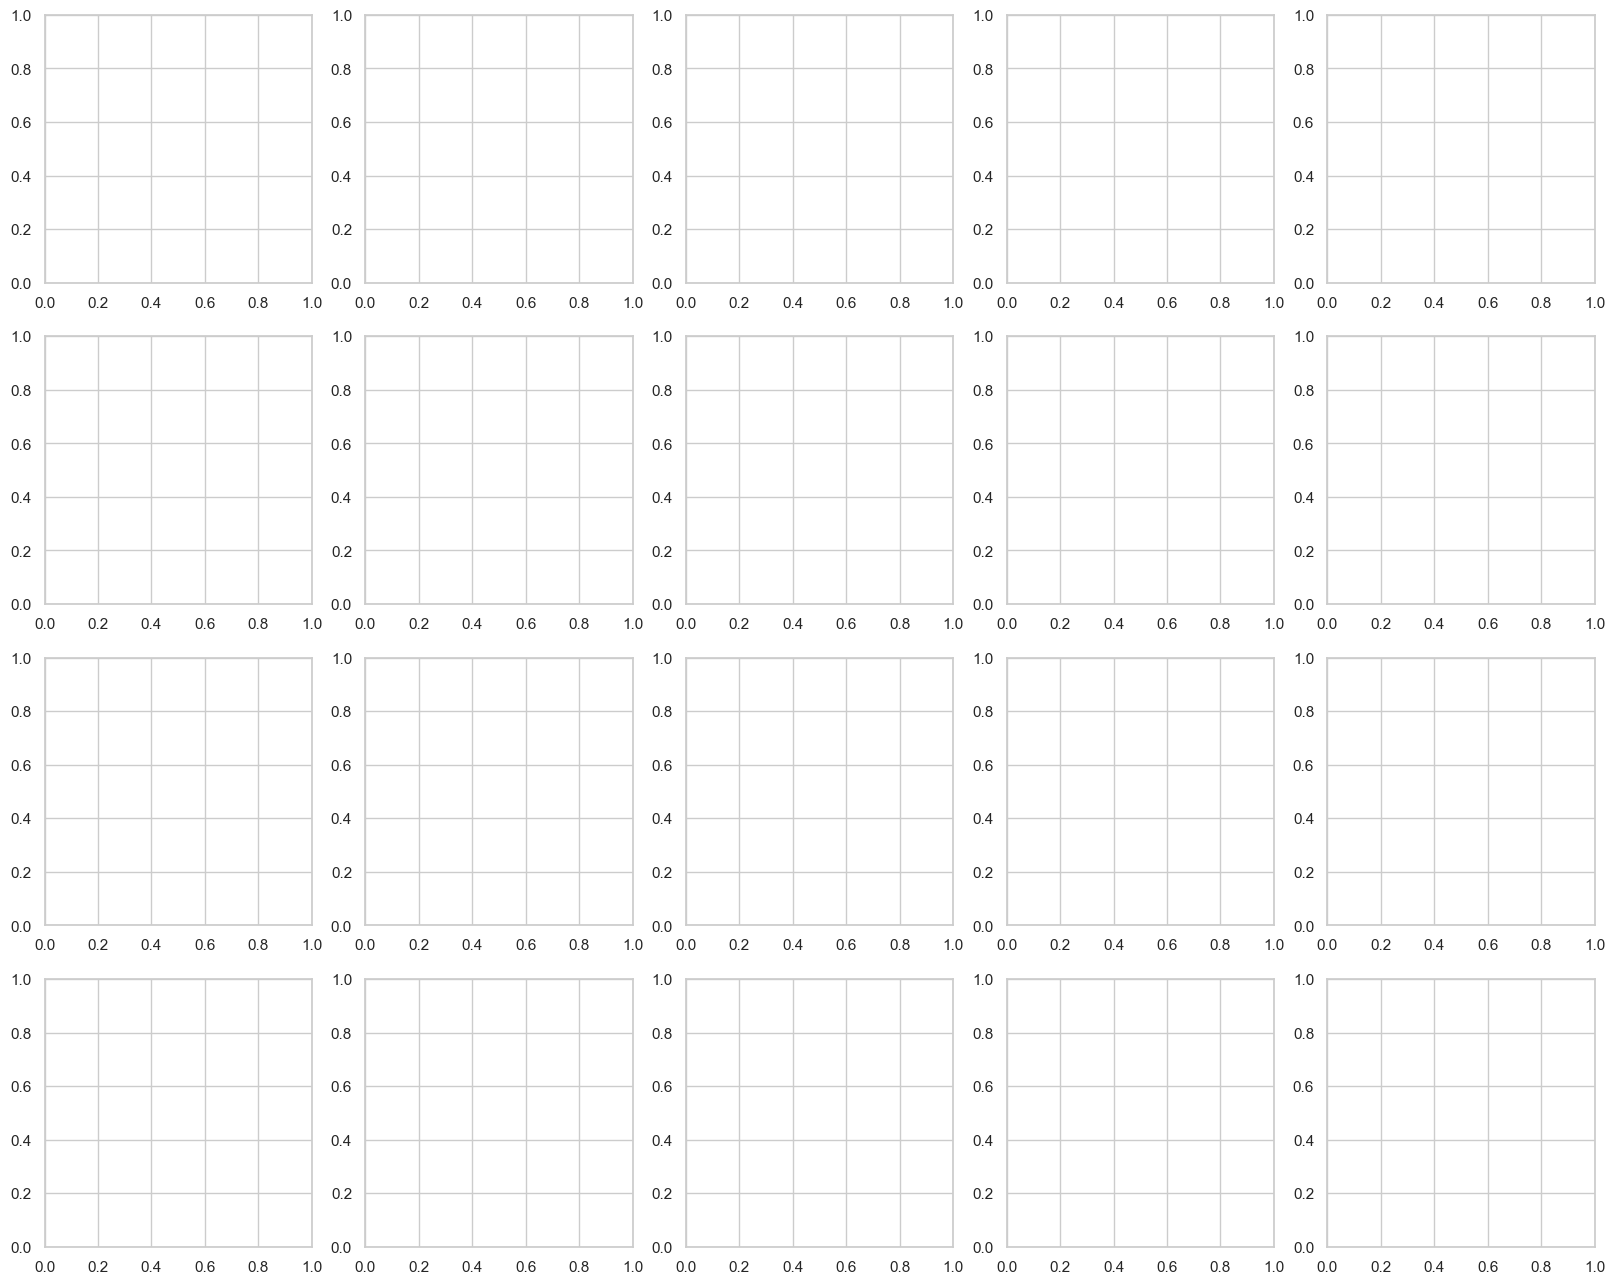

In [8]:
n = len(rows)
cols = 5
rows_plot = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_plot, cols, figsize=(20, rows_plot * 4))
axes = axes.flatten()

for i, r in enumerate(rows):
    ax = axes[i]
    resolved = resolve_portable_path(r.get('Image_Path','').strip())
    if os.path.exists(resolved):
        img = mpimg.imread(resolved)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'NO IMAGE', ha='center', va='center', fontsize=12, color='red')
    t = r['Type'][0].upper()
    price = f"Rp {int(float(r['Price'])):,}"
    ax.set_title(f"#{r['ID']} [{t}] {r['Name'][:25]}\n{r['Category']} | {price}", fontsize=9)
    ax.axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')
plt.suptitle('GALERI SEMUA PRODUK & PAKET WEDDING', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 2. Ekstraksi Fitur CBIR
### 2a. Inisialisasi Extractor & Finder

In [ ]:
EXTRACT_METHOD = "combined"
FIND_METRIC = "euclidean"

extractor = get_extractor(EXTRACT_METHOD)
finder = get_finder(FIND_METRIC)
FEATURE_DB = os.path.join("data", "metadata.json")
db = load_feature_database(FEATURE_DB)

print(f"Extractor: {type(extractor).__name__}")
print(f"Finder: {type(finder).__name__} (is_similarity={finder.is_similarity()})")
print(f"Database: {len(db.get('images',[]))} entries")

### 2b. Perbandingan Semua Metode Ekstraksi
Membandingkan dimensi fitur dari setiap extractor yang tersedia.

In [ ]:
print(f"{'Method':<20} {'Class':<30} {'Dim':>8}")
print('-'*60)
for name, cls in sorted(extractors.items()):
    try:
        inst = cls()
        sample = inst.extract(resolve_portable_path(rows[0]['Image_Path']))
        dim = sample.shape[0]
    except:
        dim = 0
    print(f"{name:<20} {cls.__name__:<30} {dim:>8}")

### 2c. Ekstraksi Satu Gambar Sampel
Ambil gambar pertama yang ditemukan untuk demo visual fitur.

In [ ]:
sample_row = None
for r in rows:
    p = resolve_portable_path(r.get('Image_Path','').strip())
    if p and os.path.exists(p):
        sample_row = (r, p)
        break

if sample_row:
    row, img_path = sample_row
    print(f"Sample: {row['Name']} ({img_path})")
    plt.figure(figsize=(4,4))
    plt.imshow(Image.open(img_path))
    plt.title(f"{row['Name']} ({row['Category']})", fontsize=12, fontweight='bold')
    plt.axis('off'); plt.show()

In [ ]:
features = extractor.extract(img_path)
deep_feat = extractor._deep.extract(img_path)
color_feat = extractor._color.extract(img_path)
texture_feat = extractor._texture.extract(img_path)

print(f"Deep ResNet50: {deep_feat.shape[0]} dim")
print(f"HSV ColorHist: {color_feat.shape[0]} dim")
print(f"LBP Texture: {texture_feat.shape[0]} dim")
print(f"Combined: {features.shape[0]} dim")
print(f"Stats: min={features.min():.4f} max={features.max():.4f} mean={features.mean():.4f}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(deep_feat, color='teal', alpha=0.7, linewidth=1)
axes[0,0].set_title(f'Deep ResNet50 ({deep_feat.shape[0]} dim)', fontsize=13, fontweight='bold')

axes[0,1].plot(color_feat, color='coral', alpha=0.7, linewidth=1)
axes[0,1].fill_between(range(len(color_feat)), color_feat, color='coral', alpha=0.15)
axes[0,1].set_title(f'HSV Color Hist ({color_feat.shape[0]} dim)', fontsize=13, fontweight='bold')

axes[1,0].plot(texture_feat, color='purple', alpha=0.7, linewidth=1)
axes[1,0].fill_between(range(len(texture_feat)), texture_feat, color='purple', alpha=0.15)
axes[1,0].set_title(f'LBP Texture ({texture_feat.shape[0]} dim)', fontsize=13, fontweight='bold')

axes[1,1].plot(features, color='darkgreen', alpha=0.7, linewidth=1)
axes[1,1].fill_between(range(len(features)), features, color='darkgreen', alpha=0.1)
axes[1,1].set_title(f'Combined ({features.shape[0]} dim)', fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()

---
## 3. Pencarian Gambar Serupa (CBIR Search)
### 3a. Scan Semua Database & Hitung Skor

In [ ]:
query_feat = extractor.extract(img_path)
images = db.get('images', [])
is_sim = finder.is_similarity()

scores = []
for entry in images:
    feat_dict = entry.get('features', {})
    feat_list = (feat_dict.get(EXTRACT_METHOD) or feat_dict.get('combined')
                 or feat_dict.get('combined_features') or feat_dict.get('deep_features'))
    if feat_list is None: continue
    candidate = np.array(feat_list, dtype=np.float32)
    if candidate.shape != query_feat.shape: continue
    scores.append((finder.compute(query_feat, candidate), entry))

scores.sort(key=lambda x: x[0], reverse=is_sim)

def calc_similarity(raw_score):
    if is_sim: return round(max(0.0, raw_score * 100.0), 2)
    max_dist = 25.0
    linear = max(0.0, 100.0 - (raw_score / max_dist * 100.0))
    sim = (linear / 100.0) ** 2 * 100.0
    return round(sim if sim >= 15.0 else 0.0, 2)

all_results = []
for raw_score, entry in scores:
    m = entry.get('metadata', {})
    all_results.append({
        'rank': len(all_results)+1,
        'id': entry.get('id'),
        'type': m.get('type','product'),
        'owner_id': m.get('owner_id',''),
        'name': m.get('name','Unknown'),
        'category': m.get('category',''),
        'price': m.get('price',0),
        'similarity': calc_similarity(raw_score),
        'distance': round(raw_score, 4),
        'path': entry.get('path'),
    })

results_df = pd.DataFrame(all_results)
print(f"Total: {len(all_results)} hasil (dari {len(images)} database)")

### 3b. Tabel Semua 20 Hasil Pencarian

In [ ]:
display(results_df[['rank','type','owner_id','name','category','similarity','distance','price']].style
    .format({'price': 'Rp {:,.0f}','similarity': '{:.1f}%','distance': '{:.4f}'})
    .applymap(lambda v: 'color: green' if isinstance(v,(int,float)) and v>=70 else ('color: orange' if isinstance(v,(int,float)) and v>=40 else ''), subset=['similarity']))

### 3c. Visualisasi Top-6 vs Query

In [ ]:
top = all_results[:6]
fig = plt.figure(figsize=(16, 7))

ax_q = plt.subplot2grid((2, 6), (0, 0), rowspan=2, colspan=2)
ax_q.imshow(Image.open(img_path))
ax_q.set_title(f"QUERY\n{row['Name']}", fontsize=12, color='darkred', fontweight='bold')
ax_q.axis('off')

for i, r in enumerate(top):
    ax = plt.subplot2grid((2, 6), (0 if i < 2 else 1, 2 + (i % 2)))
    if r['path'] and os.path.exists(r['path']):
        ax.imshow(Image.open(r['path']))
    else:
        ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
    c = 'green' if r['similarity'] >= 70 else ('orange' if r['similarity'] >= 40 else 'gray')
    ax.set_title(f"#{r['rank']}: {r['similarity']}%\n{r['name'][:20]}\nRp {r['price']:,.0f}",
                 fontsize=9, fontweight='bold', color=c)
    ax.axis('off')

plt.suptitle('TOP-6 HASIL PENCARIAN CBIR', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(); plt.show()

---
## 4. Benchmark Waktu Query
Mengukur rata-rata waktu pencarian menggunakan `benchmark_query_time()`.

In [ ]:
def do_search(path):
    q = extractor.extract(path)
    for e in images:
        fl = e['features'].get(EXTRACT_METHOD) or e['features'].get('combined')
        if fl is not None:
            _ = finder.compute(q, np.array(fl, dtype=np.float32))

valid_paths = [r['path'] for r in all_results if r['path'] and os.path.exists(r['path'])]
if valid_paths:
    bench = benchmark_query_time(do_search, valid_paths[:5], n_runs=3)
    print(f"Query time benchmark ({len(valid_paths[:5])} images x 3 runs):")
    print(f"  Mean: {bench['mean']:.4f}s")
    print(f"  Std:  {bench['std']:.4f}s")
    print(f"  Min:  {bench['min']:.4f}s")
    print(f"  Max:  {bench['max']:.4f}s")

---
## 5. Evaluasi Metrik Retrieval
### 5a. MAP, MRR, First Rank Accuracy
Kategori digunakan sebagai ground truth: item dalam kategori yang sama dianggap relevan.

In [ ]:
categories = df['Category'].unique()
queries = []
for cat in categories:
    same_cat_ids = df[df['Category'] == cat]['ID'].astype(int).tolist()
    if len(same_cat_ids) < 2: continue
    relevant = set(same_cat_ids)
    retrieved = same_cat_ids[:]
    random.shuffle(retrieved)
    queries.append((retrieved, relevant))

report = evaluation_report(queries)
print(f"Queries: {report['n_queries']} kategori")
print(f"  MAP:                    {report['map']:.4f}")
print(f"  MRR:                    {report['mrr']:.4f}")
print(f"  First Rank Accuracy:    {report['first_rank_accuracy']:.2%}")

### 5b. Akurasi per Kategori

In [ ]:
print(f"{'Kategori':<20} {'Total':>6} {'Correct@1':>10} {'Acc@1':>8}")
print('-'*50)
for cat in categories:
    ids = df[df['Category'] == cat]['ID'].astype(int).tolist()
    correct = 0
    for qid in ids:
        qpath = None
        for e in images:
            if e['metadata'].get('owner_id') == qid:
                qpath = e.get('path')
                break
        if not qpath or not os.path.exists(qpath): continue
        qf = extractor.extract(qpath)
        best = None
        best_id = None
        for e in images:
            fl = e['features'].get(EXTRACT_METHOD) or e['features'].get('combined')
            if fl is None: continue
            d = finder.compute(qf, np.array(fl, dtype=np.float32))
            if best is None or (not is_sim and d < best) or (is_sim and d > best):
                best = d
                best_id = e['metadata'].get('owner_id')
        if best_id in ids:
            correct += 1
    acc = correct / len(ids) if ids else 0
    print(f"{cat:<20} {len(ids):>6} {correct:>10} {acc:>7.1%}")

---
## 6. Kurva Konversi Jarak Euclidean ke Similarity
$$\text{Linear} = \max(0, 100 - (\text{Distance} / 25.0 \times 100))$$
$$\text{Similarity} = (\text{Linear} / 100)^2 \times 100$$
Skor < 15% dianggap tidak cocok.

In [ ]:
distances = np.linspace(0, 30, 300)
similarities = []
for d in distances:
    linear = max(0.0, 100.0 - (d / 25.0 * 100.0))
    sim = (linear / 100.0) ** 2 * 100.0
    similarities.append(sim if sim >= 15.0 else 0.0)

plt.figure(figsize=(12, 5))
plt.plot(distances, similarities, color='purple', linewidth=2.5)
plt.axvline(x=25.0, color='red', linestyle='--', label='Max Distance Threshold')
plt.axhline(y=15.0, color='orange', linestyle=':', label='Min Similarity (15%)')
plt.fill_between(distances, similarities, color='purple', alpha=0.1)
plt.title('Konversi Jarak Euclidean ke Similarity Score', fontsize=14, fontweight='bold')
plt.xlabel('Jarak Euclidean'); plt.ylabel('Similarity (%)'); plt.legend(); plt.grid(True, linestyle=':')
plt.show()

print(f"Contoh: distance=0   -> similarity=100%")
print(f"        distance=5   -> similarity={calc_similarity(5):.1f}%")
print(f"        distance=10  -> similarity={calc_similarity(10):.1f}%")
print(f"        distance=15  -> similarity={calc_similarity(15):.1f}%")
print(f"        distance=25  -> similarity={calc_similarity(25):.1f}%")

---
## 7. Metadata JSON (Feature Database)
Semua entry di `metadata.json` yang dipakai Flask API.

In [ ]:
with open(FEATURE_DB, 'r', encoding='utf-8') as f:
    meta = json.load(f)
images = meta.get('images', [])

print(f"Total entry: {len(images)}")
print()
print(f"{'#':>3} {'Type':>8} {'Owner':>5}  Name")
print('-'*60)
for img in images:
    m = img.get('metadata', {})
    print(f"{img['id']:3d} {str(m.get('type','?')):>8} {str(m.get('owner_id','?')):>5}  {m.get('name','?')}")

if images:
    first = images[0]
    print("\n--- Struktur entry pertama ---")
    print(f"  metadata keys: {list(first.get('metadata',{}).keys())}")
    feat = first.get('features',{})
    print(f"  features keys ({len(feat)}): {list(feat.keys())[:10]}...")
    for k in ['combined','deep','color_histogram','lbp']:
        v = feat.get(k)
        if isinstance(v, list):
            print(f"    {k}: {len(v)} dim, preview={[round(x,4) for x in v[:3]]}")

---
## Kesimpulan
Notebook ini mendemonstrasikan secara **lengkap**:
1. **Validasi dataset** — 20 item (10 products + 10 packages), 6 kategori
2. **Validasi path gambar** — status existensi setiap file
3. **Gallery visual** — seluruh produk/paket
4. **Perbandingan extractor** — dimensi fitur tiap metode
5. **Ekstraksi fitur** — Deep (ResNet50), Color (HSV), Texture (LBP), Combined
6. **Pencarian CBIR** — ranking seluruh 20 item dengan similarity score
7. **Benchmark waktu** — rata-rata query time
8. **Evaluasi metrik** — MAP, MRR, First Rank Accuracy, akurasi per kategori
9. **Similarity curve** — konversi jarak Euclidean -> persentase
10. **Metadata JSON** — daftar lengkap feature database

### Perintah Penting:
```bash
# Rebuild index:
python -m src.features.build_features --method combined
# Jalankan server:
python app.py
```